In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc


In [2]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rc('font', family='serif')

s_size = 5
latex_size = 20
scat = "scatter"
alp = 0.3
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams["xtick.minor.visible"] =  True
mpl.rcParams["ytick.minor.visible"] =  True
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['xtick.minor.width'] = 1.0

mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['ytick.minor.width'] = 1.0
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 1.5

mpl.rcParams.update({"axes.grid" : True, "grid.color": "black","grid.alpha": "0.3" })
mpl.rcParams['font.size'] = 16
plt.rc('legend', loc='best',fancybox=True,markerscale=2) 

In [3]:
# Read the data
data_files = [ 'CHWtill_hjj_big_data_data_aug.csv'
]
df_chw_hjj = pd.concat(
    [pd.read_csv(f) for f in data_files])
#df_chw_hjj.reset_index(drop=True, inplace=True)
print(df_chw_hjj.keys())

Index(['jet0Pt', 'jet0Eta', 'jet0Phi', 'jet1Pt', 'jet1Eta', 'jet1Phi', 'hPt',
       'hEta', 'hPhi', 'deltaphi', 'sign_w'],
      dtype='object')


In [4]:
df_chw_hjj

,jet0Pt,jet0Eta,jet0Phi,jet1Pt,jet1Eta,jet1Phi,hPt,hEta,hPhi,deltaphi,sign_w
0,1.672154,-1.843204,-2.729061,0.453930,2.680678,-2.133047,2.063609,-0.203925,0.536326,-0.596014,-1.0
1,0.838243,2.420060,0.634051,0.654418,-3.925637,-1.472383,0.755615,-3.366255,2.935448,2.106434,1.0
2,1.069747,-3.010563,2.193521,0.607195,3.378601,-2.764860,1.352552,2.252185,-0.497576,-1.324804,-1.0
3,0.955432,-1.819065,-2.268580,0.690238,2.735088,2.150509,1.003968,2.890846,0.154654,1.864097,1.0
4,1.739630,2.422367,2.142933,1.025206,-1.822045,0.927030,2.305829,1.977988,-1.428701,1.215903,1.0
...,...,...,...,...,...,...,...,...,...,...,...
307643,1.637737,2.061481,-1.836928,0.879578,-3.351331,2.667458,1.691415,-0.789086,0.770856,1.778800,1.0
307644,0.863166,-2.054948,-2.210073,0.528735,3.961637,1.956576,0.742186,0.297952,0.276821,2.116537,-1.0
307645,1.436319,0.445910,0.331807,0.763661,-2.707941,2.918419,0.884151,0.386789,-2.337280,-2.586612,-1.0
307646,0.768070,-2.647665,-2.000775,0.359936,0.542979,0.403940,0.556790,-0.378414,1.590189,-2.404715,-1.0


In [5]:
df_chw_hjj.jet0Phi - df_chw_hjj.jet1Phi

0        -0.596014
1         2.106434
2         4.958381
3        -4.419089
4         1.215903
            ...   
307643   -4.504385
307644   -4.166649
307645   -2.586612
307646   -2.404715
307647    1.623394
Length: 307648, dtype: float64

In [6]:
filtered_df = df_chw_hjj.dropna()
print(len(filtered_df), len(df_chw_hjj))

307648 307648


In [7]:

print(df_chw_hjj['sign_w'].unique())


[-1.  1.]


In [8]:
def plot_hist(df, column, weight=None, bins=30, xmin=None, xmax=None, label=None):
    data = df[column].values
    weights = df[weight].values if weight else None
    
    if xmin is None:
        xmin = data.min()
    if xmax is None:
        xmax = data.max()
    
    bin_edges = np.linspace(xmin, xmax, bins + 1)
    
    plt.hist(data, bins=bin_edges, weights=weights, 
             color='steelblue', 
             edgecolor='black',
             alpha=0.7,
             label=label)  # Add label here
    plt.xlabel(column)
    plt.ylabel('Total no. of Events')
    plt.grid(False)
    plt.tight_layout()
    if label:
        plt.legend()  # Show legend if label is provided
    return plt


In [9]:

def plot_diff_xsec(df, column, weight=None, bins=30, xmin=None, xmax=None):
    data = df[column].values
    weights = df[weight].values if weight else None
    
    # Determine range
    if xmin is None:
        xmin = data.min()
    if xmax is None:
        xmax = data.max()
    
    bin_edges = np.linspace(xmin, xmax, bins + 1)
    

    counts, _ = np.histogram(data, bins=bin_edges, weights=weights)
    
   
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # Compute differential cross section: dσ/dX
    d_sigma = counts / bin_widths
    
    ## What is the total cross section and luminosity and eff.???

    # Normalize to unity
    total = np.sum(d_sigma * bin_widths)
    if total > 0:
        d_sigma /= total
    
    # Plot as bar chart
    plt.bar(bin_centers, d_sigma, width=bin_widths,
            color='steelblue', alpha=0.7)
    
    plt.xlabel(column)
    plt.ylabel(f'Normalized dσ/d{column} [fb/unit]')
    plt.grid(False)
    plt.tight_layout()
    
    return plt


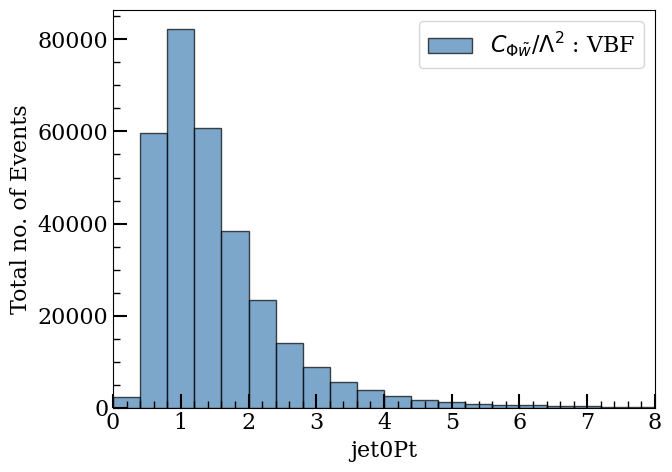

In [10]:
# 1. Basic histogram
plot_hist(df_chw_hjj, 'jet0Pt', bins=20, xmin=0.,xmax=8, label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')
#plot_hist(df_chw_hjj, 'jet1Pt', bins=20, xmin=0.,xmax=8, label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')

plt.show()

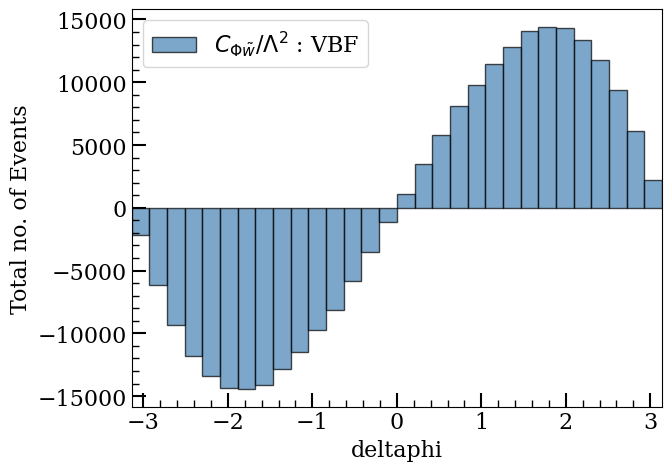

<Figure size 700x500 with 0 Axes>

In [11]:
plot_hist(df_chw_hjj, 'deltaphi', bins=30, weight='sign_w', label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')
plt.show()
plt.savefig('')


In [12]:
features = [
    'jet0Pt','jet0Eta','jet0Phi',
    'jet1Pt','jet1Eta','jet1Phi',
    'hPt','hEta','hPhi',
    'deltaphi'
]

X = df_chw_hjj[features].values
y = np.where(df_chw_hjj['sign_w'] > 0, 1, 0)  # + → 1, − → 0
weights = df_chw_hjj['sign_w'].values         # sign values as it is 
print(y)

[0 1 0 ... 0 0 1]


In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [14]:
X

array([[ 0.15529056, -0.79598551, -1.50418174, ..., -0.12775528,
         0.29608254, -0.32853451],
       [-0.68012217,  1.04510001,  0.34947103, ..., -2.10889723,
         1.62053381,  1.16110738],
       [-0.44820123, -1.30010797,  1.2090071 , ...,  1.41095287,
        -0.27469038, -0.73025782],
       ...,
       [-0.0809693 ,  0.1925657 ,  0.18288271, ...,  0.24231645,
        -1.29031128, -1.42579086],
       [-0.75042135, -1.14339079, -1.10277059, ..., -0.23706943,
         0.87787457, -1.32552574],
       [ 0.52886507,  0.73987865,  0.03033322, ..., -0.43315602,
         1.65496404,  0.8948461 ]])

In [15]:
class VBFDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
dataset = VBFDataset(X, y)
loader = DataLoader(dataset, batch_size=256, shuffle=True)


## The interference term of SM and EFT is antisymmetric => odd upcer CP. tanh being an odd function performs better than ReLU 

In [17]:
class CPClassifier(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    #simple forward pass to all sequential layers until architectures like ResNets
    #(skip connections), transformers, or networks that change behavior during inference

    def forward(self, x):
        return self.net(x).squeeze()


In [18]:
device = torch.device("cpu")
model = CPClassifier(len(features))
print(model)


CPClassifier(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

epochs = 30


In [20]:
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch} | Loss {avg_loss:.5f}")



Epoch 0 | Loss 0.23408
Epoch 1 | Loss 0.20257
Epoch 2 | Loss 0.19675
Epoch 3 | Loss 0.19329
Epoch 4 | Loss 0.19267
Epoch 5 | Loss 0.19232
Epoch 6 | Loss 0.19217
Epoch 7 | Loss 0.19202
Epoch 8 | Loss 0.19188
Epoch 9 | Loss 0.19178
Epoch 10 | Loss 0.19170
Epoch 11 | Loss 0.19155
Epoch 12 | Loss 0.19139
Epoch 13 | Loss 0.19131
Epoch 14 | Loss 0.19120
Epoch 15 | Loss 0.19113
Epoch 16 | Loss 0.19110
Epoch 17 | Loss 0.19110
Epoch 18 | Loss 0.19100
Epoch 19 | Loss 0.19099
Epoch 20 | Loss 0.19096
Epoch 21 | Loss 0.19096
Epoch 22 | Loss 0.19088
Epoch 23 | Loss 0.19080
Epoch 24 | Loss 0.19084
Epoch 25 | Loss 0.19082
Epoch 26 | Loss 0.19083
Epoch 27 | Loss 0.19072
Epoch 28 | Loss 0.19073
Epoch 29 | Loss 0.19071


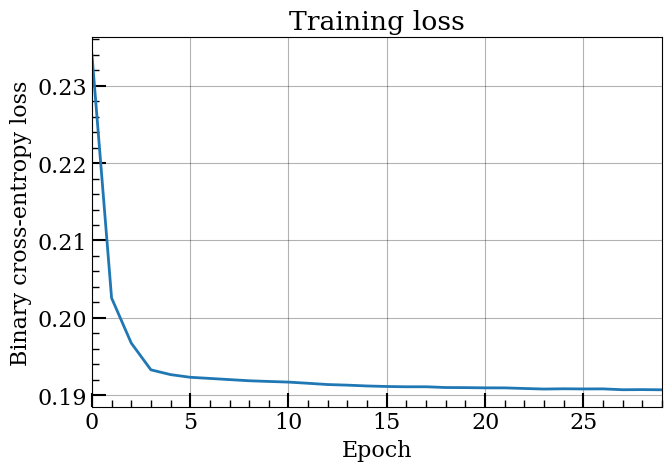

In [21]:

plt.plot(train_losses, lw=2)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Constructing the CP-odd observable

In [22]:
with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32)
    P_plus = model(X_tensor).numpy()

O_NN = 2.0 * P_plus - 1.0    # Same as Eq.(8) 


In [23]:
O_NN.min()

-0.99061805

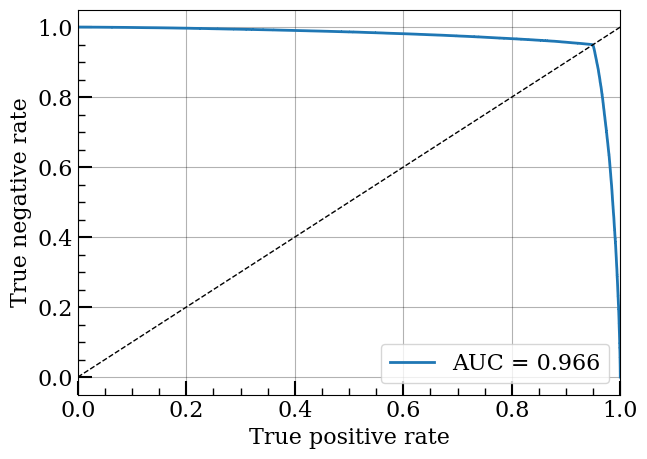

In [24]:
y_true = y
y_score = P_plus

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.plot(tpr, 1 - fpr, lw=2,
         label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlabel("True positive rate")
plt.ylabel("True negative rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
def plot_ONN_distribution(O_NN, sign_w, bins=30):
    bin_edges = np.linspace(-1, 1, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    hist = np.zeros(bins)

    for i in range(bins):
        mask = (O_NN >= bin_edges[i]) & (O_NN < bin_edges[i+1])
        hist[i] = np.sum(sign_w[mask])   #weighted by interference sign

    plt.figure(figsize=(7,5))
    plt.bar(
        bin_centers,
        hist,
        width=bin_widths,
        color='steelblue',
        alpha=0.8
    )
    plt.axhline(0, color='black', lw=1)

    plt.xlabel(r'$O_{\rm NN}$')
    plt.ylabel(r'No. of Events')
    plt.title(r'ML-constructed CP-odd observable')
    plt.tight_layout()
    plt.show()


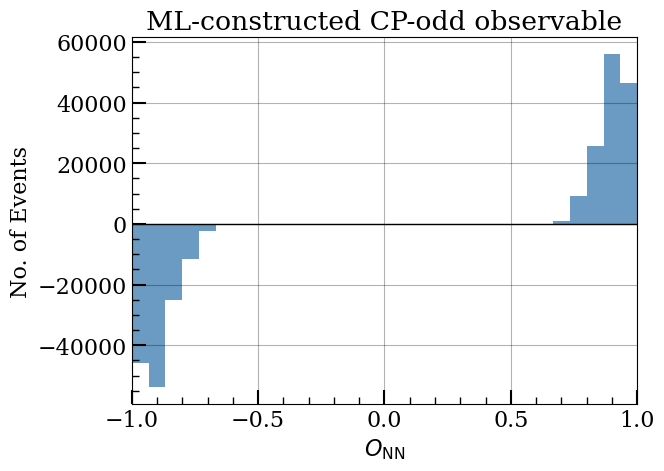

In [26]:
plot_ONN_distribution(O_NN, df_chw_hjj['sign_w'].values)

In [35]:
from IPython.display import Math
A_NN = np.mean(df_chw_hjj['sign_w'].values * O_NN)
A_trad = np.mean(df_chw_hjj['sign_w'].values * np.sin(df_chw_hjj['deltaphi'].values))

print(rf'Av. O_NN_CP: {A_NN}')
print(rf'Av Delta Phi: {A_trad}')



Av. O_NN_CP: 0.8066173051169097
Av Delta Phi: 0.698825728200129
